# Informalidad laboral en Argentina: Regresión Logística vs. Support Vector Machine

**Actividad obligatoria – Clase 6: Aprendizaje Supervisado (III)**

## Problema

En Argentina, trabajar en relación de dependencia no garantiza estar registrado: muchas personas asalariadas trabajan "en negro", es decir, su empleador no les hace aportes jubilatorios. El objetivo de esta notebook es **predecir si una persona asalariada es informal** (no tiene descuento jubilatorio) a partir de sus características personales y de su empleo.

- **Tipo de problema:** clasificación binaria (1 = informal, 0 = formal).
- **Modelos comparados:** Regresión Logística y Support Vector Machine (SVM).
- **Datos:** microdatos de la Encuesta Permanente de Hogares (EPH), primer trimestre de 2026. Fuente: Instituto Nacional de Estadística y Censos (INDEC).

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

sns.set_theme(style="whitegrid")

## 2. Carga de datos

La base individual de la EPH tiene una fila por persona encuestada. El archivo usa punto y coma (`;`) como separador.

In [2]:
eph = pd.read_csv("../Datos/usu_individual_T126.txt", sep=";", low_memory=False)
print("Personas encuestadas:", eph.shape[0])
print("Columnas:", eph.shape[1])

Personas encuestadas: 43739
Columnas: 234


## 3. Población de estudio y variable objetivo

Nos quedamos con las personas **ocupadas** (`ESTADO` = 1) que trabajan como **obrero o empleado** (`CAT_OCUP` = 3), es decir, los asalariados.

La variable objetivo sale de la pregunta `PP07H`: *"¿Por ese trabajo tiene descuento jubilatorio?"* (1 = Sí, 2 = No). Una persona asalariada sin descuento jubilatorio es **informal**.

In [3]:
asal = eph[(eph["ESTADO"] == 1) & (eph["CAT_OCUP"] == 3)].copy()
print("Asalariados:", len(asal))
asal["PP07H"].value_counts().rename({1: "Con descuento (formal)", 2: "Sin descuento (informal)"})

Asalariados: 13938


PP07H
Con descuento (formal)      8694
Sin descuento (informal)    5244
Name: count, dtype: int64

## 4. Selección de variables y limpieza

### Variables predictoras elegidas

| Variable | Código EPH | Tipo |
|---|---|---|
| Edad | `CH06` | Numérica |
| Horas trabajadas en la semana | `PP3E_TOT` | Numérica |
| Ingreso de la ocupación principal (en logaritmo) | `P21` | Numérica |
| Sexo | `CH04` | Categórica |
| Nivel educativo | `NIVEL_ED` | Categórica |
| Región | `REGION` | Categórica |
| Sector (estatal, privado u otro) | `PP04A` | Categórica |
| Tamaño del establecimiento | `PP04C`, `PP04C99`, `PP04B1` | Categórica |

### Variables excluidas a propósito

Algunas preguntas de la EPH están tan ligadas a la informalidad que prácticamente **contienen la respuesta**. Si las usáramos, el modelo acertaría casi siempre sin aprender nada útil (esto se llama *fuga de información* o *data leakage*). Por eso se excluyen:

- `EMPLEO`: es la clasificación formal/informal que ya hace el INDEC.
- `PP07G1` a `PP07G4`: vacaciones pagas, aguinaldo, días por enfermedad y obra social.
- `PP07K`: si le dan recibo de sueldo.
- `CH08`: cobertura médica "por la que paga o le descuentan".
- `PP07I`, `PP07I2`, `PP07I3`, `PP07I4`: aportes propios y si el empleador hace descuentos, factura o tiene contador.

### Limpieza

Según el diseño de registro del INDEC:
- En los ingresos, `-9` significa "no respuesta". Además se descartan los ingresos iguales a 0.
- En las horas, `0` corresponde a ocupados que no trabajaron en la semana de referencia y `999` es "no sabe/no responde".
- El tamaño del establecimiento tiene 12 categorías detalladas (`PP04C`) y, para quienes no saben el número exacto, una pregunta resumida (`PP04C99`). Las combinamos en 4 grupos. El servicio doméstico (`PP04B1` = 1) se trata como una categoría propia, porque trabaja en casas de familia.

In [4]:
# Filtrar ingresos y horas válidos
asal = asal[(asal["P21"] > 0) & (asal["PP3E_TOT"] > 0) & (asal["PP3E_TOT"] < 999)]

def tamano_establecimiento(fila):
    if fila["PP04B1"] == 1:
        return "Servicio doméstico"
    c, c99 = fila["PP04C"], fila["PP04C99"]
    if 1 <= c <= 5 or c99 == 1:
        return "Hasta 5"
    if 6 <= c <= 8 or c99 == 2:
        return "6 a 40"
    if 9 <= c <= 12 or c99 == 3:
        return "Más de 40"
    return "Ns/Nr"

datos = pd.DataFrame({
    "edad": asal["CH06"],
    "horas": asal["PP3E_TOT"],
    "log_ingreso": np.log(asal["P21"]),
    "sexo": asal["CH04"].map({1: "Varón", 2: "Mujer"}),
    "nivel_educativo": asal["NIVEL_ED"].map({
        7: "Sin instrucción", 1: "Primario incompleto", 2: "Primario completo",
        3: "Secundario incompleto", 4: "Secundario completo",
        5: "Superior incompleto", 6: "Superior completo"}),
    "region": asal["REGION"].map({1: "GBA", 40: "Noroeste", 41: "Noreste",
                                  42: "Cuyo", 43: "Pampeana", 44: "Patagonia"}),
    "sector": asal["PP04A"].map({1: "Estatal", 2: "Privado", 3: "Otro"}),
    "tamano": asal.apply(tamano_establecimiento, axis=1),
    "informal": (asal["PP07H"] == 2).astype(int),
})

print("Filas finales:", len(datos))
print("Valores faltantes:", datos.isna().sum().sum())
datos.head()

Filas finales: 10225
Valores faltantes: 0


,edad,horas,log_ingreso,sexo,nivel_educativo,region,sector,tamano,informal
5,56,20.0,13.304685,Mujer,Superior incompleto,Noroeste,Estatal,6 a 40,0
9,48,12.0,11.918391,Mujer,Primario completo,Noroeste,Privado,Servicio doméstico,1
10,26,40.0,13.997832,Mujer,Secundario completo,Noroeste,Privado,Hasta 5,0
11,25,40.0,13.304685,Mujer,Secundario completo,Noroeste,Privado,Hasta 5,1
14,49,30.0,13.122363,Varón,Superior completo,Noroeste,Estatal,6 a 40,0


Usamos el **logaritmo del ingreso** porque los ingresos tienen una distribución muy asimétrica (pocos ingresos muy altos). El logaritmo la vuelve más pareja, lo que ayuda especialmente a la Regresión Logística y al SVM, que son sensibles a la escala de las variables.

## 5. Análisis exploratorio

### 5.1 Balance de clases

informal
Formal      0.606
Informal    0.394
Name: proportion, dtype: float64


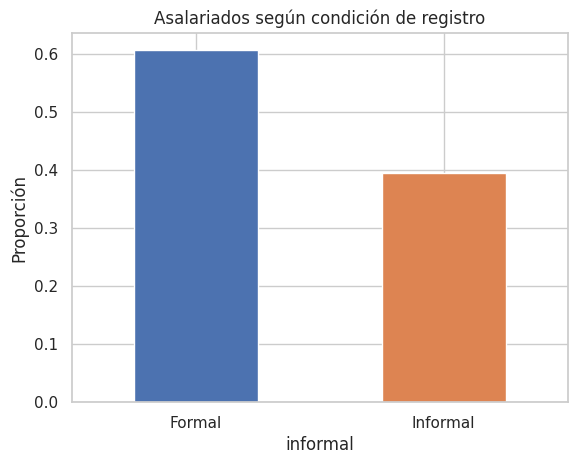

In [5]:
proporcion = datos["informal"].value_counts(normalize=True).rename({0: "Formal", 1: "Informal"})
print(proporcion.round(3))

ax = proporcion.plot(kind="bar", color=["#4C72B0", "#DD8452"], rot=0)
ax.set_title("Asalariados según condición de registro")
ax.set_ylabel("Proporción")
plt.show()

Las clases están **moderadamente desbalanceadas**: alrededor de 6 de cada 10 asalariados son formales. Un modelo que dijera siempre "formal" ya acertaría en ese porcentaje, así que la exactitud sola no alcanza para evaluar: también vamos a mirar la precisión, el recall y el F1-score de la clase informal.

### 5.2 Informalidad según variables categóricas

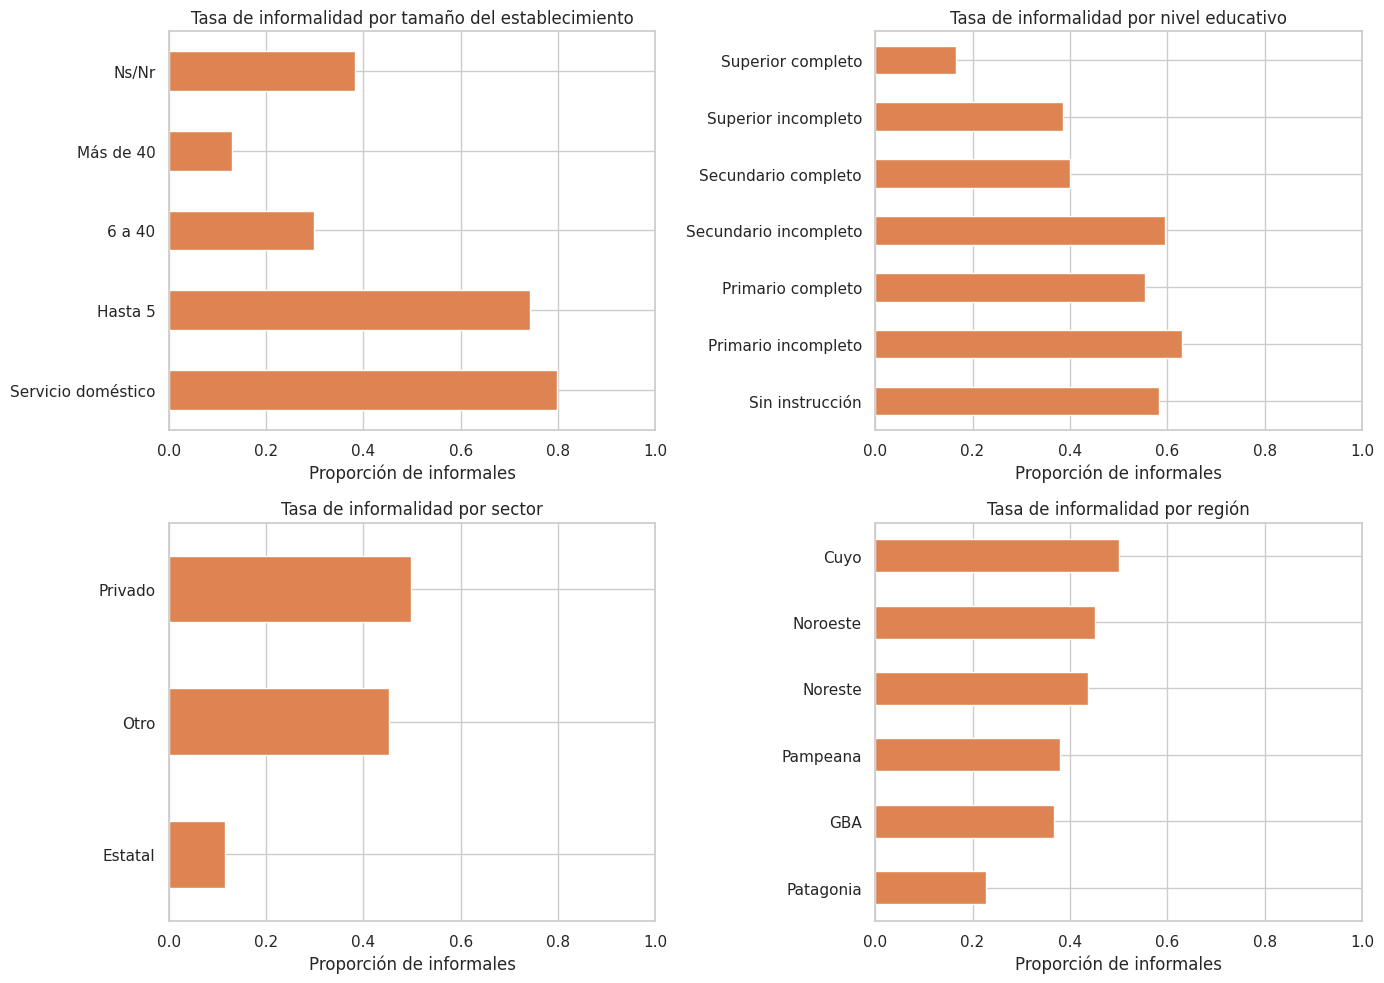

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
orden_ed = ["Sin instrucción", "Primario incompleto", "Primario completo", "Secundario incompleto",
            "Secundario completo", "Superior incompleto", "Superior completo"]
orden_tam = ["Servicio doméstico", "Hasta 5", "6 a 40", "Más de 40", "Ns/Nr"]

for ax, var, orden in [(axes[0, 0], "tamano", orden_tam),
                       (axes[0, 1], "nivel_educativo", orden_ed),
                       (axes[1, 0], "sector", None),
                       (axes[1, 1], "region", None)]:
    tasa = datos.groupby(var)["informal"].mean()
    tasa = tasa.reindex(orden) if orden else tasa.sort_values()
    tasa.plot(kind="barh", ax=ax, color="#DD8452")
    titulos = {"tamano": "tamaño del establecimiento", "nivel_educativo": "nivel educativo",
               "sector": "sector", "region": "región"}
    ax.set_title(f"Tasa de informalidad por {titulos[var]}")
    ax.set_xlabel("Proporción de informales")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### 5.3 Variables numéricas

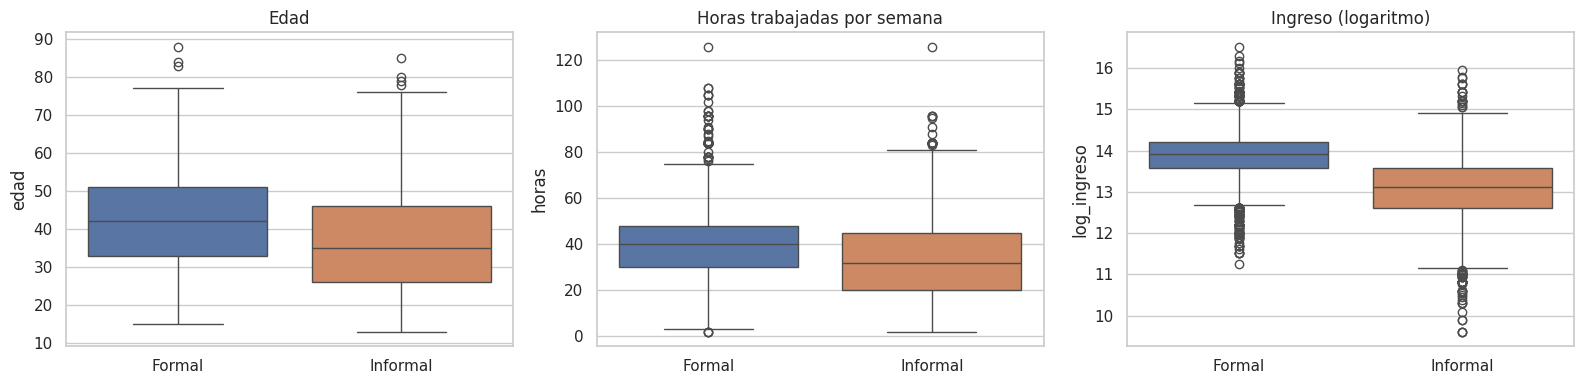

,edad,horas,log_ingreso
informal,,,
Formal,42.0,40.0,13.910821
Informal,35.0,32.0,13.122363


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, var in zip(axes, ["edad", "horas", "log_ingreso"]):
    sns.boxplot(data=datos, x="informal", y=var, ax=ax, hue="informal",
                palette=["#4C72B0", "#DD8452"], legend=False)
    ax.set_xticks([0, 1], ["Formal", "Informal"])
    ax.set_xlabel("")
    ax.set_title({"edad": "Edad", "horas": "Horas trabajadas por semana",
                  "log_ingreso": "Ingreso (logaritmo)"}[var])
plt.tight_layout()
plt.show()

datos.groupby("informal")[["edad", "horas", "log_ingreso"]].median().rename(index={0: "Formal", 1: "Informal"})

In [8]:
# Mediana del ingreso en pesos (deshaciendo el logaritmo con np.exp)
mediana_ingreso = np.exp(datos.groupby("informal")["log_ingreso"].median()).round(-3)
print("Mediana del ingreso de la ocupación principal (en pesos):")
print(mediana_ingreso.rename({0: "Formal", 1: "Informal"}).map("${:,.0f}".format))

# Tasa de informalidad por sexo
print("\nTasa de informalidad por sexo:")
print(datos.groupby("sexo")["informal"].mean().round(3))

Mediana del ingreso de la ocupación principal (en pesos):
informal
Formal      $1,100,000
Informal      $500,000
Name: log_ingreso, dtype: str

Tasa de informalidad por sexo:
sexo
Mujer    0.427
Varón    0.366
Name: informal, dtype: float64


**Para completar con tus palabras:** qué se observa en los gráficos. Por ejemplo, cómo cambia la informalidad según el tamaño del establecimiento, el nivel educativo y el sector, y en qué se diferencian formales e informales en edad, horas e ingresos.

## 6. Preparación para el modelado

- **División entrenamiento/prueba:** 80% para entrenar y 20% para evaluar. Usamos `stratify` para que las dos partes tengan la misma proporción de informales.
- **Variables numéricas:** se estandarizan (media 0, desvío 1). Es fundamental para el SVM, porque calcula distancias: si una variable tiene valores mucho más grandes que otra, dominaría el cálculo del margen.
- **Variables categóricas:** se transforman con *One-Hot Encoding* (una columna 0/1 por categoría).

Todo se arma dentro de un `Pipeline`, para que el preprocesamiento se aprenda solo con los datos de entrenamiento y se aplique igual a los de prueba.

In [9]:
X = datos.drop(columns="informal")
y = datos["informal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

numericas = ["edad", "horas", "log_ingreso"]
categoricas = ["sexo", "nivel_educativo", "region", "sector", "tamano"]

preprocesamiento = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
])

print("Entrenamiento:", X_train.shape[0], "| Prueba:", X_test.shape[0])

Entrenamiento: 8180 | Prueba: 2045


### Modelo de referencia (baseline)

Antes de entrenar los modelos, vemos cuánto acierta un clasificador "tonto" que siempre predice la clase más frecuente. Cualquier modelo útil tiene que superarlo.

In [10]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Exactitud del baseline:", round(accuracy_score(y_test, baseline.predict(X_test)), 3))
print("F1 (clase informal) del baseline:", f1_score(y_test, baseline.predict(X_test), zero_division=0))

Exactitud del baseline: 0.606
F1 (clase informal) del baseline: 0.0


## 7. Modelo 1: Regresión Logística

La Regresión Logística estima la **probabilidad** de que una persona sea informal combinando linealmente sus variables y pasando el resultado por la función sigmoide. Si la probabilidad supera 0,5, la clasifica como informal. La frontera de decisión es lineal.

**Hiperparámetros que ajustamos:**
- `C`: controla la regularización. Valores chicos penalizan más los coeficientes grandes y evitan el sobreajuste.
- `class_weight`: con `"balanced"`, el modelo le da más peso a los errores en la clase minoritaria (informales), lo que suele mejorar el recall.

Elegimos la mejor combinación con validación cruzada de 5 particiones, optimizando el F1-score.

In [11]:
pipe_lr = Pipeline([("pre", preprocesamiento),
                    ("modelo", LogisticRegression(max_iter=1000))])

grilla_lr = {"modelo__C": [0.01, 0.1, 1, 10],
             "modelo__class_weight": [None, "balanced"]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
busqueda_lr = GridSearchCV(pipe_lr, grilla_lr, scoring="f1", cv=cv)
busqueda_lr.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_lr.best_params_)
print("F1 en validación cruzada:", round(busqueda_lr.best_score_, 3))

lr = busqueda_lr.best_estimator_
pred_lr = lr.predict(X_test)
print(classification_report(y_test, pred_lr, target_names=["Formal", "Informal"], digits=3))

Mejores hiperparámetros: {'modelo__C': 0.1, 'modelo__class_weight': 'balanced'}
F1 en validación cruzada: 0.783
              precision    recall  f1-score   support

      Formal      0.863     0.833     0.848      1239
    Informal      0.756     0.797     0.776       806

    accuracy                          0.819      2045
   macro avg      0.810     0.815     0.812      2045
weighted avg      0.821     0.819     0.819      2045



### Interpretación de los coeficientes

Una ventaja de la Regresión Logística es que se puede interpretar: un coeficiente positivo aumenta la probabilidad de ser informal y uno negativo la disminuye. Como las numéricas están estandarizadas, sus coeficientes se refieren a un aumento de un desvío estándar.

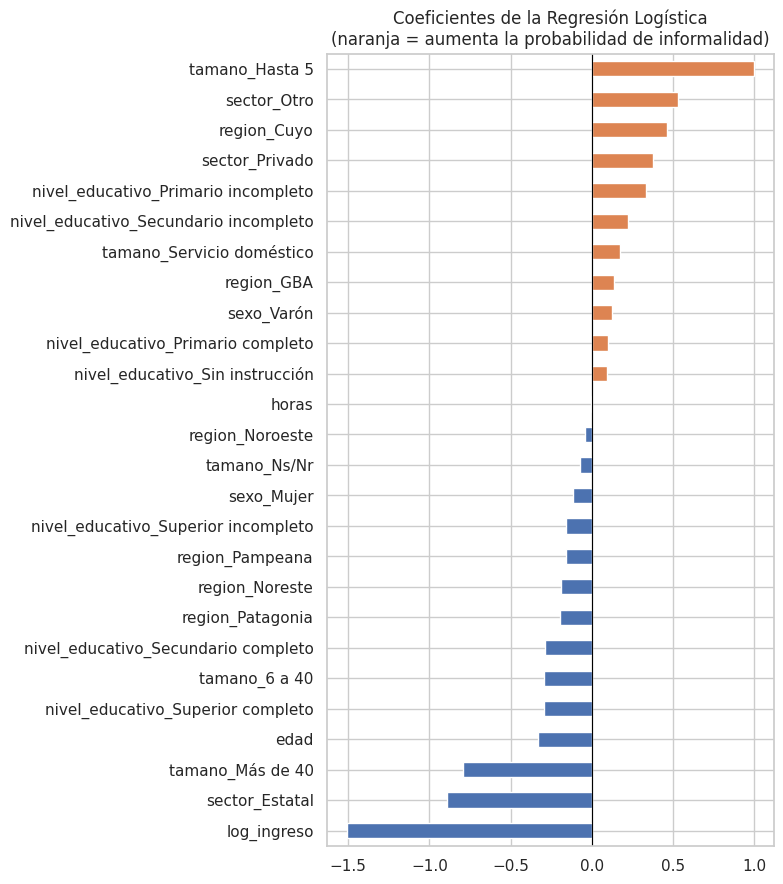

In [12]:
nombres = lr.named_steps["pre"].get_feature_names_out()
nombres = [n.replace("num__", "").replace("cat__", "") for n in nombres]
coef = pd.Series(lr.named_steps["modelo"].coef_[0], index=nombres).sort_values()

plt.figure(figsize=(8, 9))
coef.plot(kind="barh", color=["#4C72B0" if c < 0 else "#DD8452" for c in coef])
plt.title("Coeficientes de la Regresión Logística\n(naranja = aumenta la probabilidad de informalidad)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Modelo 2: Support Vector Machine (SVM)

El SVM busca el **hiperplano** que separa las dos clases con el **margen máximo**, es decir, con la mayor distancia posible a los puntos más cercanos de cada clase (los **vectores de soporte**).

Cuando los datos no se pueden separar con una frontera lineal, el SVM usa el **truco del kernel**: transforma implícitamente los datos a un espacio de mayor dimensión donde sí son separables. Vamos a comparar dos kernels:
- **Lineal:** frontera de decisión recta, como la de la Regresión Logística.
- **RBF (función de base radial):** kernel de propósito general, que permite fronteras curvas.

**Hiperparámetros que ajustamos:**
- `kernel`: lineal o RBF.
- `C`: cuánto se penalizan los puntos mal clasificados o dentro del margen. Un `C` chico permite un margen más ancho con algunos errores; uno grande busca clasificar todo bien aunque el margen sea angosto (riesgo de sobreajuste).
- `gamma` (solo RBF): cuánto influye cada punto de entrenamiento. Valores altos generan fronteras más irregulares.

Usamos `class_weight="balanced"` por el desbalance de clases. Como el SVM tarda bastante más en entrenar que la Regresión Logística, la validación cruzada es de 3 particiones. **Esta celda puede tardar alrededor de un minuto.**

In [13]:
pipe_svm = Pipeline([("pre", preprocesamiento),
                     ("modelo", SVC(class_weight="balanced"))])

grilla_svm = [
    {"modelo__kernel": ["linear"], "modelo__C": [0.1, 1]},
    {"modelo__kernel": ["rbf"], "modelo__C": [0.1, 1, 10], "modelo__gamma": ["scale", 0.01, 0.1]},
]

busqueda_svm = GridSearchCV(pipe_svm, grilla_svm, scoring="f1", cv=3, n_jobs=-1)
busqueda_svm.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_svm.best_params_)
print("F1 en validación cruzada:", round(busqueda_svm.best_score_, 3))

svm = busqueda_svm.best_estimator_
pred_svm = svm.predict(X_test)
print(classification_report(y_test, pred_svm, target_names=["Formal", "Informal"], digits=3))

Mejores hiperparámetros: {'modelo__C': 1, 'modelo__gamma': 0.1, 'modelo__kernel': 'rbf'}
F1 en validación cruzada: 0.794


              precision    recall  f1-score   support

      Formal      0.868     0.834     0.851      1239
    Informal      0.759     0.805     0.781       806

    accuracy                          0.822      2045
   macro avg      0.814     0.819     0.816      2045
weighted avg      0.825     0.822     0.823      2045



### ¿Aporta algo el truco del kernel?

Comparamos el mejor resultado con kernel lineal contra el mejor con kernel RBF.

In [14]:
resultados = pd.DataFrame(busqueda_svm.cv_results_)
resultados["kernel"] = resultados["param_modelo__kernel"]
print(resultados.groupby("kernel")["mean_test_score"].max().round(3).rename("Mejor F1 en validación"))
print("\nVectores de soporte del modelo final:", svm.named_steps["modelo"].n_support_.sum(),
      "de", len(X_train), "puntos de entrenamiento")

kernel
linear    0.783
rbf       0.794
Name: Mejor F1 en validación, dtype: float64

Vectores de soporte del modelo final: 3387 de 8180 puntos de entrenamiento


## 9. Comparación de los dos modelos

In [15]:
def metricas(nombre, y_real, y_pred, puntaje):
    return {"Modelo": nombre,
            "Exactitud": accuracy_score(y_real, y_pred),
            "Precisión (informal)": precision_score(y_real, y_pred),
            "Recall (informal)": recall_score(y_real, y_pred),
            "F1 (informal)": f1_score(y_real, y_pred),
            "AUC-ROC": roc_auc_score(y_real, puntaje)}

tabla = pd.DataFrame([
    metricas("Regresión Logística", y_test, pred_lr, lr.decision_function(X_test)),
    metricas("SVM", y_test, pred_svm, svm.decision_function(X_test)),
]).set_index("Modelo").round(3)
tabla

,Exactitud,Precisión (informal),Recall (informal),F1 (informal),AUC-ROC
Modelo,,,,,
Regresión Logística,0.819,0.756,0.797,0.776,0.895
SVM,0.822,0.759,0.805,0.781,0.903


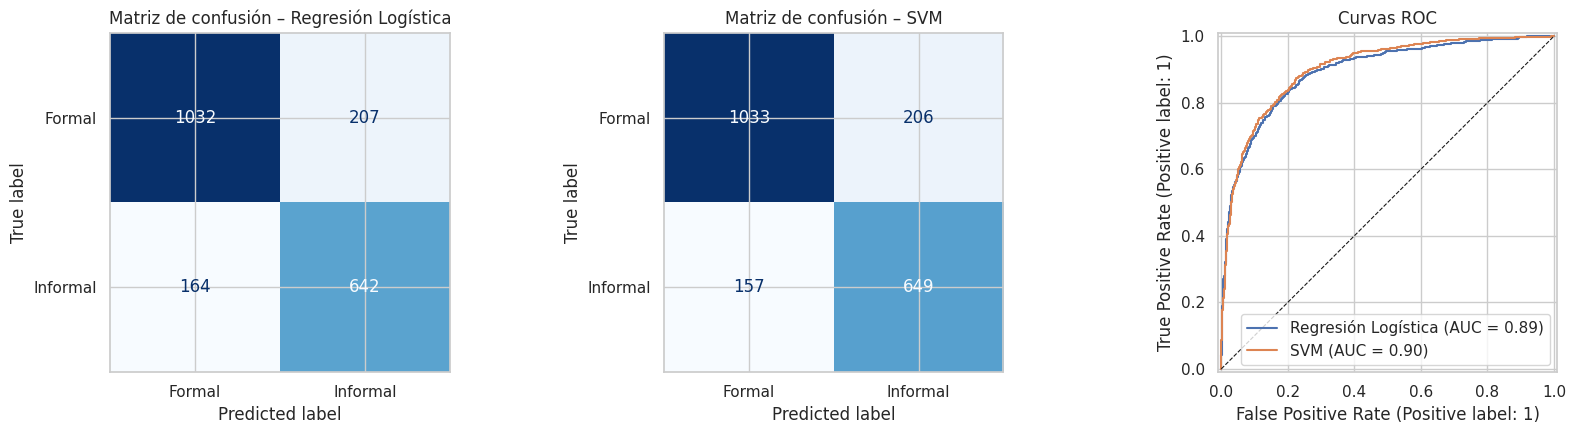

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, modelo, pred, titulo in [(axes[0], lr, pred_lr, "Regresión Logística"),
                                 (axes[1], svm, pred_svm, "SVM")]:
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Formal", "Informal"],
                                            cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Matriz de confusión – {titulo}")

RocCurveDisplay.from_estimator(lr, X_test, y_test, name="Regresión Logística", ax=axes[2])
RocCurveDisplay.from_estimator(svm, X_test, y_test, name="SVM", ax=axes[2])
axes[2].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[2].set_title("Curvas ROC")
plt.tight_layout()
plt.show()

## 10. Conclusiones

**Para completar con tus palabras**, a partir de los resultados de arriba. Algunas preguntas que te pueden guiar:

1. ¿Los dos modelos superan claramente al baseline? ¿Por cuánto?
2. ¿Cuál tiene mejor F1 y mejor recall en la clase informal? ¿La diferencia es grande o chica?
3. En el SVM, ¿el kernel RBF mejoró mucho respecto del lineal? ¿Qué te dice eso sobre si la relación entre las variables y la informalidad es aproximadamente lineal?
4. Más allá de las métricas: ¿qué modelo elegirías si tuvieras que explicarle los resultados a alguien (por ejemplo, a un organismo público)? Pensá en la interpretabilidad de los coeficientes y en el tiempo de entrenamiento.
5. ¿Qué variables resultaron más importantes según los coeficientes de la Regresión Logística? ¿Coincide con lo que viste en el análisis exploratorio?
6. Limitaciones: los datos son de un solo trimestre, el modelo no usa los ponderadores de la EPH, y quedaron afuera variables como la rama de actividad.